In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [15]:
from pathlib import Path

import pandas as pd

def find_in_parents(relative_path: Path) -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find '{relative_path.as_posix()}' from '{cwd}' or any parent directory."
    )

b0005_features_path = find_in_parents(Path("data") / "nasa_all_features.csv")
df = pd.read_csv(b0005_features_path)

print("Loaded:", b0005_features_path)
df.head()

Loaded: D:\projects\battery-rul-prediction\data\nasa_all_features.csv


,battery,cycle,discharge_capacity,avg_voltage,end_voltage,discharge_time,cv_charge_time,Re,Rct,SOH,RUL
0,B0005,1,1.856487,3.529829,3.277170,3690.234,7051.265,0.044669,0.069456,1.000000,124
1,B0005,2,1.846327,3.537320,3.300245,3672.344,7398.594,0.044669,0.069456,0.994527,123
2,B0005,3,1.835349,3.543737,3.327451,3651.641,7369.875,0.044669,0.069456,0.988614,122
3,B0005,4,1.835263,3.543666,3.314182,3631.563,7303.422,0.044669,0.069456,0.988567,121
4,B0005,5,1.834646,3.542343,3.305497,3629.172,7390.719,0.044669,0.069456,0.988235,120


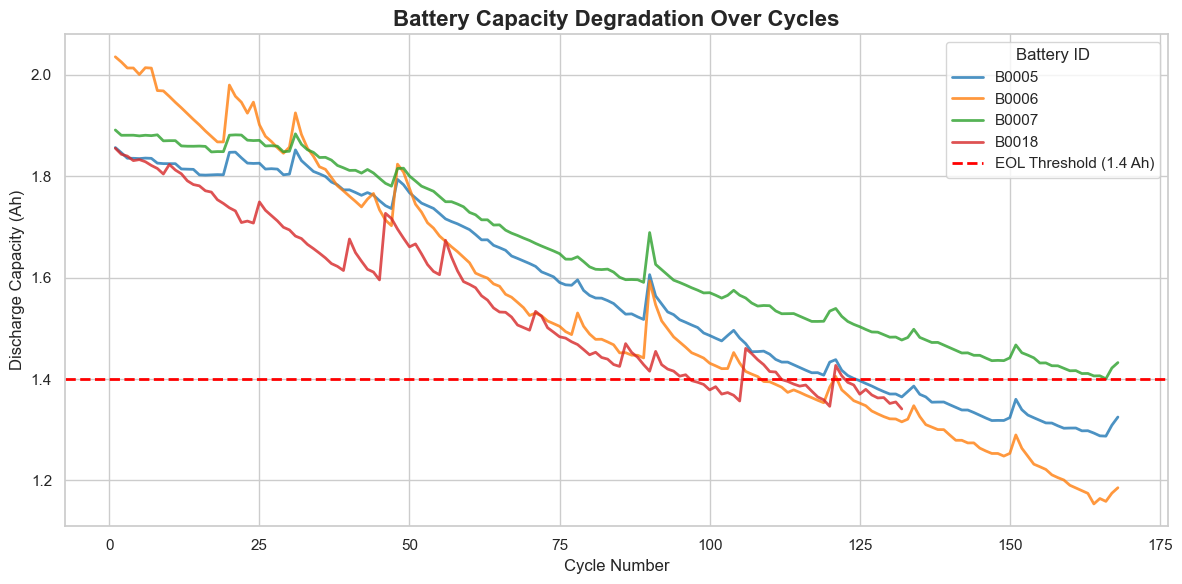

In [16]:
# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")

# 3. Create the figure
plt.figure(figsize=(12, 6))

# 4. Plot the full discharge capacity over all cycles
sns.lineplot(
    data=df, 
    x='cycle', 
    y='discharge_capacity', 
    hue='battery', 
    palette='tab10',  
    linewidth=2,
    alpha=0.8
)

# 5. Add the End-of-Life (EOL) threshold line
plt.axhline(y=1.4, color='red', linestyle='--', linewidth=2, label='EOL Threshold (1.4 Ah)')

# 6. Customize Labels and Title
plt.title('Battery Capacity Degradation Over Cycles', fontsize=16, fontweight='bold')
plt.xlabel('Cycle Number', fontsize=12)
plt.ylabel('Discharge Capacity (Ah)', fontsize=12)

# 7. Refine the legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Battery ID', fontsize=11, title_fontsize=12)

# 8. Show the plot
plt.tight_layout()
plt.show()

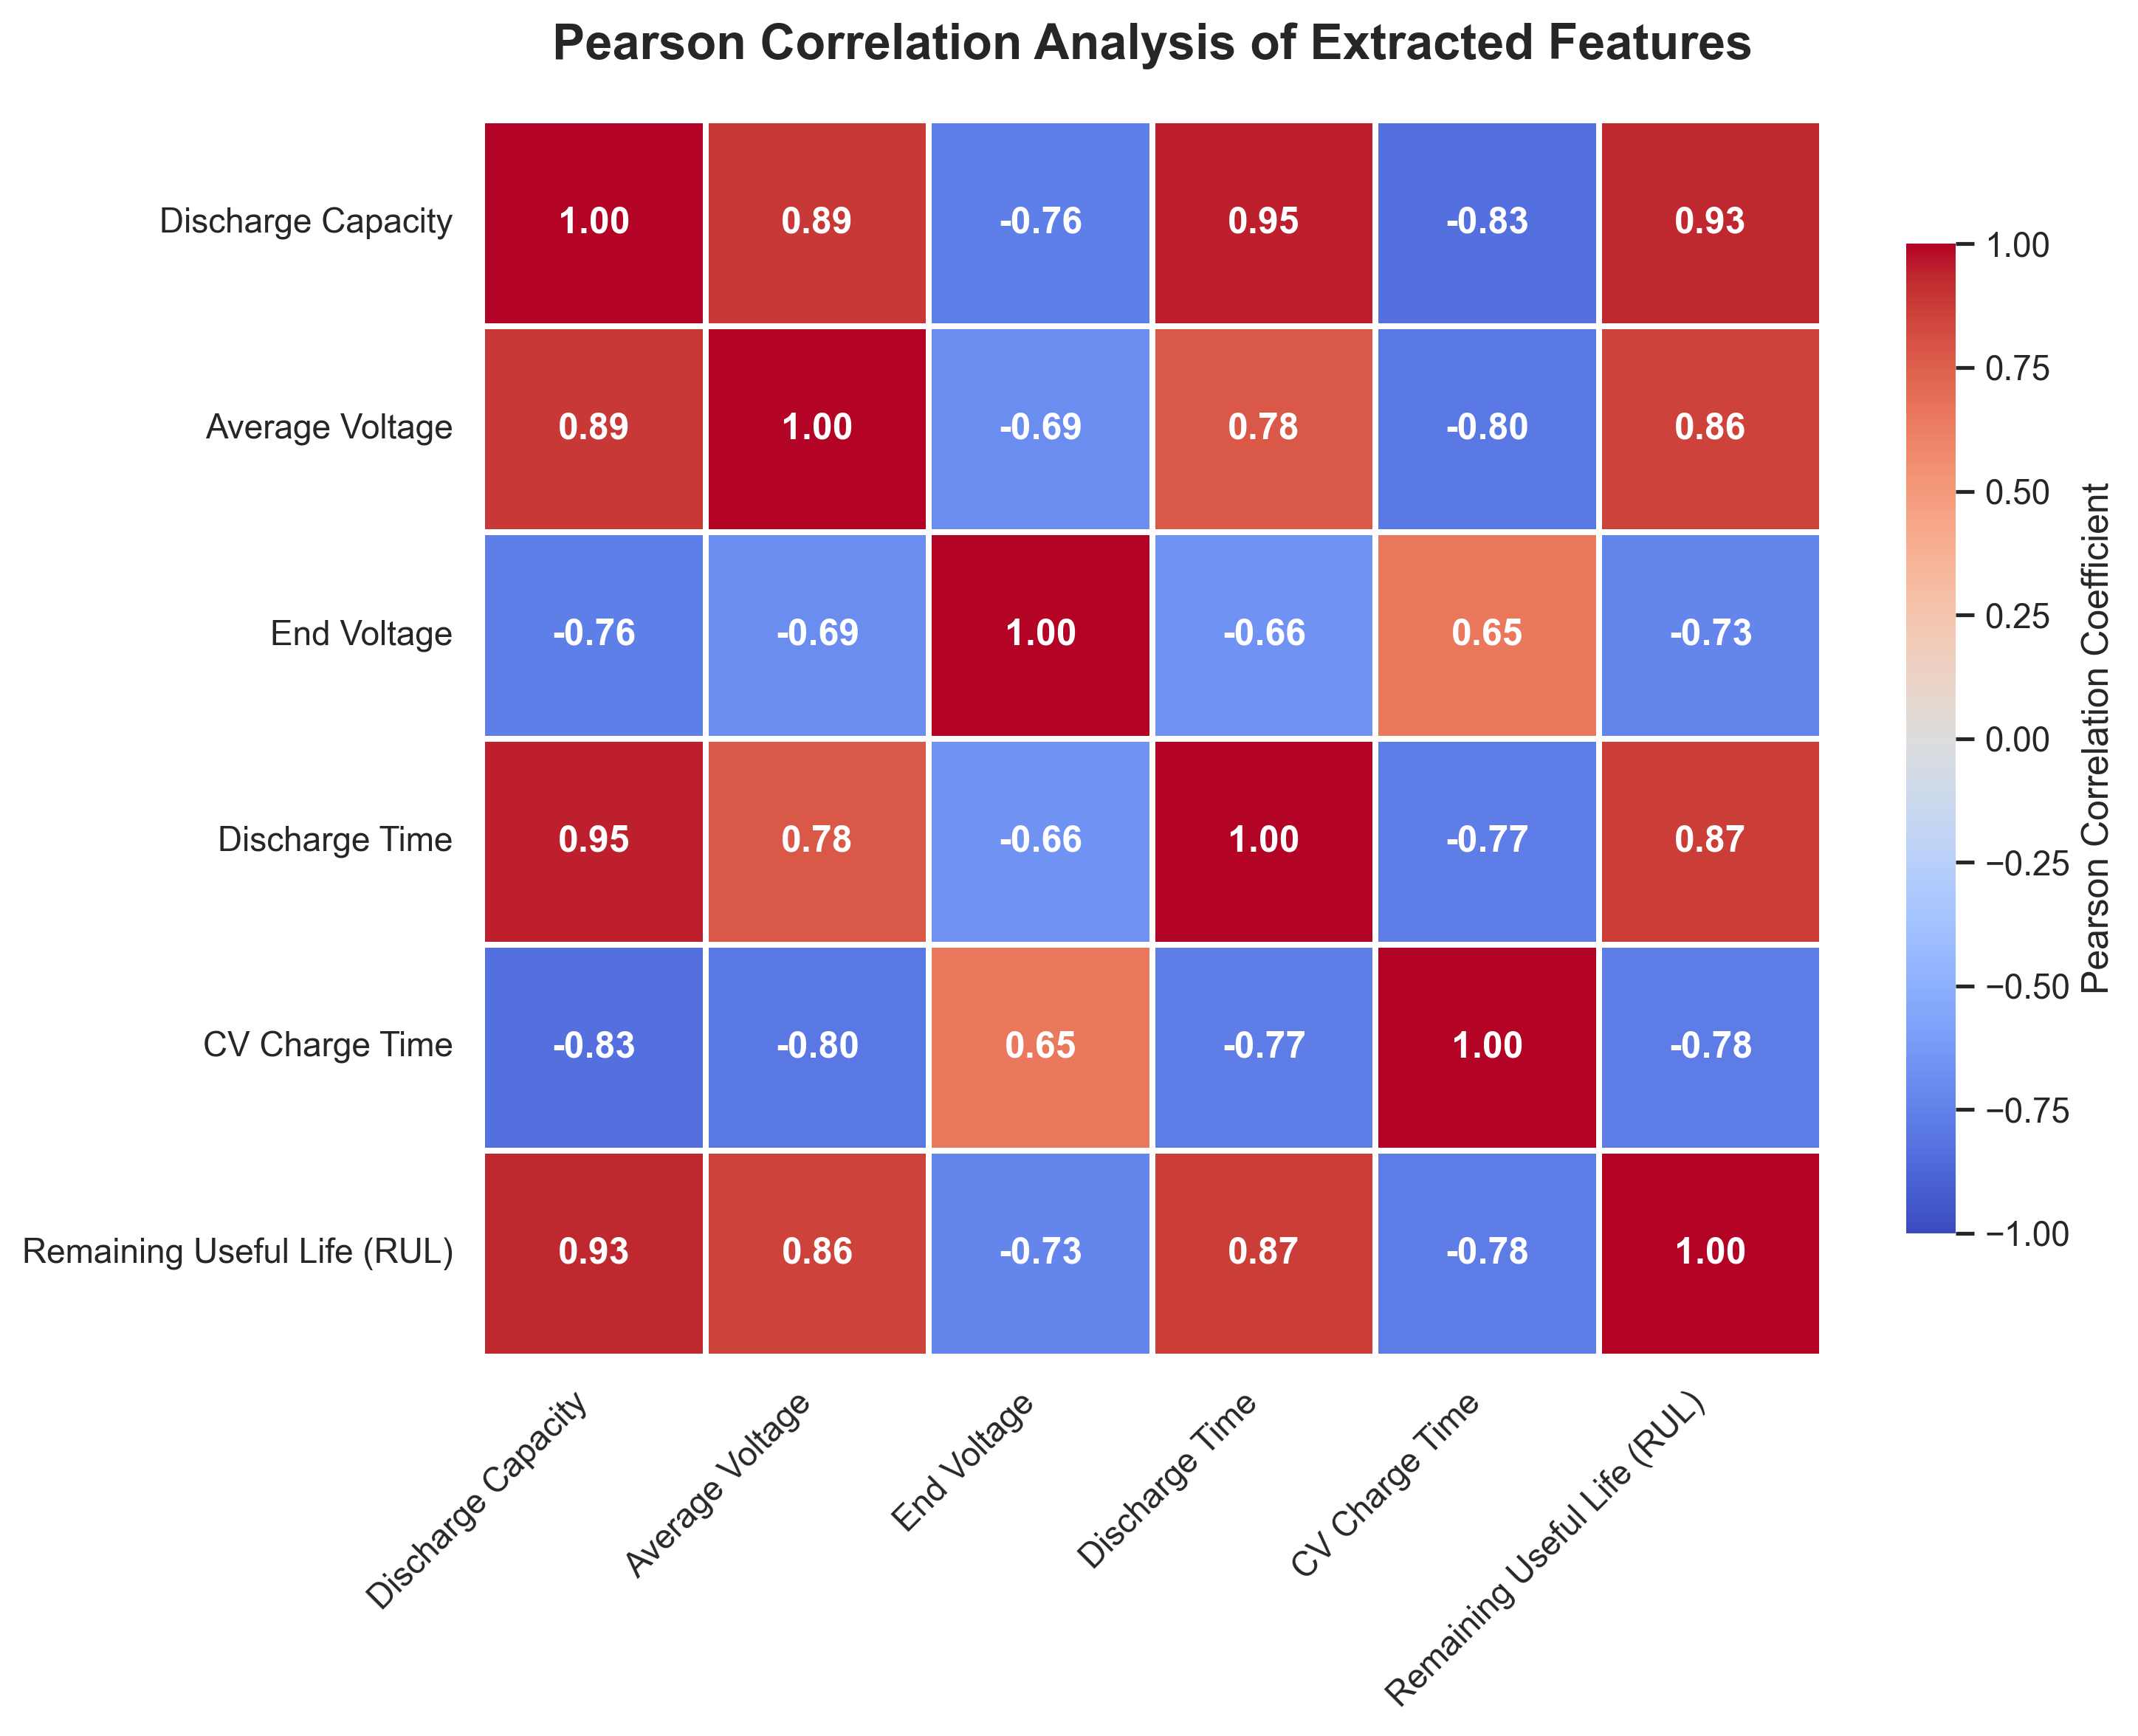

Success! High-resolution heatmap saved as 'Fig1_Correlation_Heatmap.png'


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# 2. Filter strictly for the training batteries (Exclude B0018 to prevent data leakage)
train_batteries = ['B0005', 'B0006', 'B0007']
df_train = df[df['battery'].isin(train_batteries)].copy()

# 3. Select only the extracted macroscopic features and the target (RUL)
features_of_interest = [
    'discharge_capacity', 
    'avg_voltage', 
    'end_voltage', 
    'discharge_time', 
    'cv_charge_time', 
    'RUL'
]
df_heatmap = df_train[features_of_interest]

# 4. Rename columns for a cleaner, professional look in the research paper
clean_names = {
    'discharge_capacity': 'Discharge Capacity',
    'avg_voltage': 'Average Voltage',
    'end_voltage': 'End Voltage',
    'discharge_time': 'Discharge Time',
    'cv_charge_time': 'CV Charge Time',
    'RUL': 'Remaining Useful Life (RUL)'
}
df_heatmap = df_heatmap.rename(columns=clean_names)

# 5. Calculate the Pearson Correlation Matrix
corr_matrix = df_heatmap.corr(method='pearson')

# 6. Set up the matplotlib figure (Size and High Resolution for IEEE)
plt.figure(figsize=(10, 8), dpi=300)

# 7. Draw the heatmap with seaborn
sns.heatmap(
    corr_matrix, 
    annot=True,            # Show the actual correlation numbers
    fmt=".2f",             # Format to 2 decimal places
    cmap="coolwarm",       # Professional Blue-to-Red diverging palette
    vmin=-1, vmax=1,       # Lock the scale from -1 to 1
    linewidths=1.5,        # Add white lines between squares for readability
    linecolor='white',
    cbar_kws={'label': 'Pearson Correlation Coefficient', 'shrink': 0.8},
    annot_kws={'size': 12, 'weight': 'bold'} # Make numbers pop
)

# 8. Customize title and layout
plt.title("Pearson Correlation Analysis of Extracted Features", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# 9. Save the figure as a high-quality PNG for your Word Document
plt.savefig("Fig1_Correlation_Heatmap.png", format='png', dpi=300, bbox_inches='tight')

# 10. Show the plot in Jupyter
plt.show()

print("Success! High-resolution heatmap saved as 'Fig1_Correlation_Heatmap.png'")

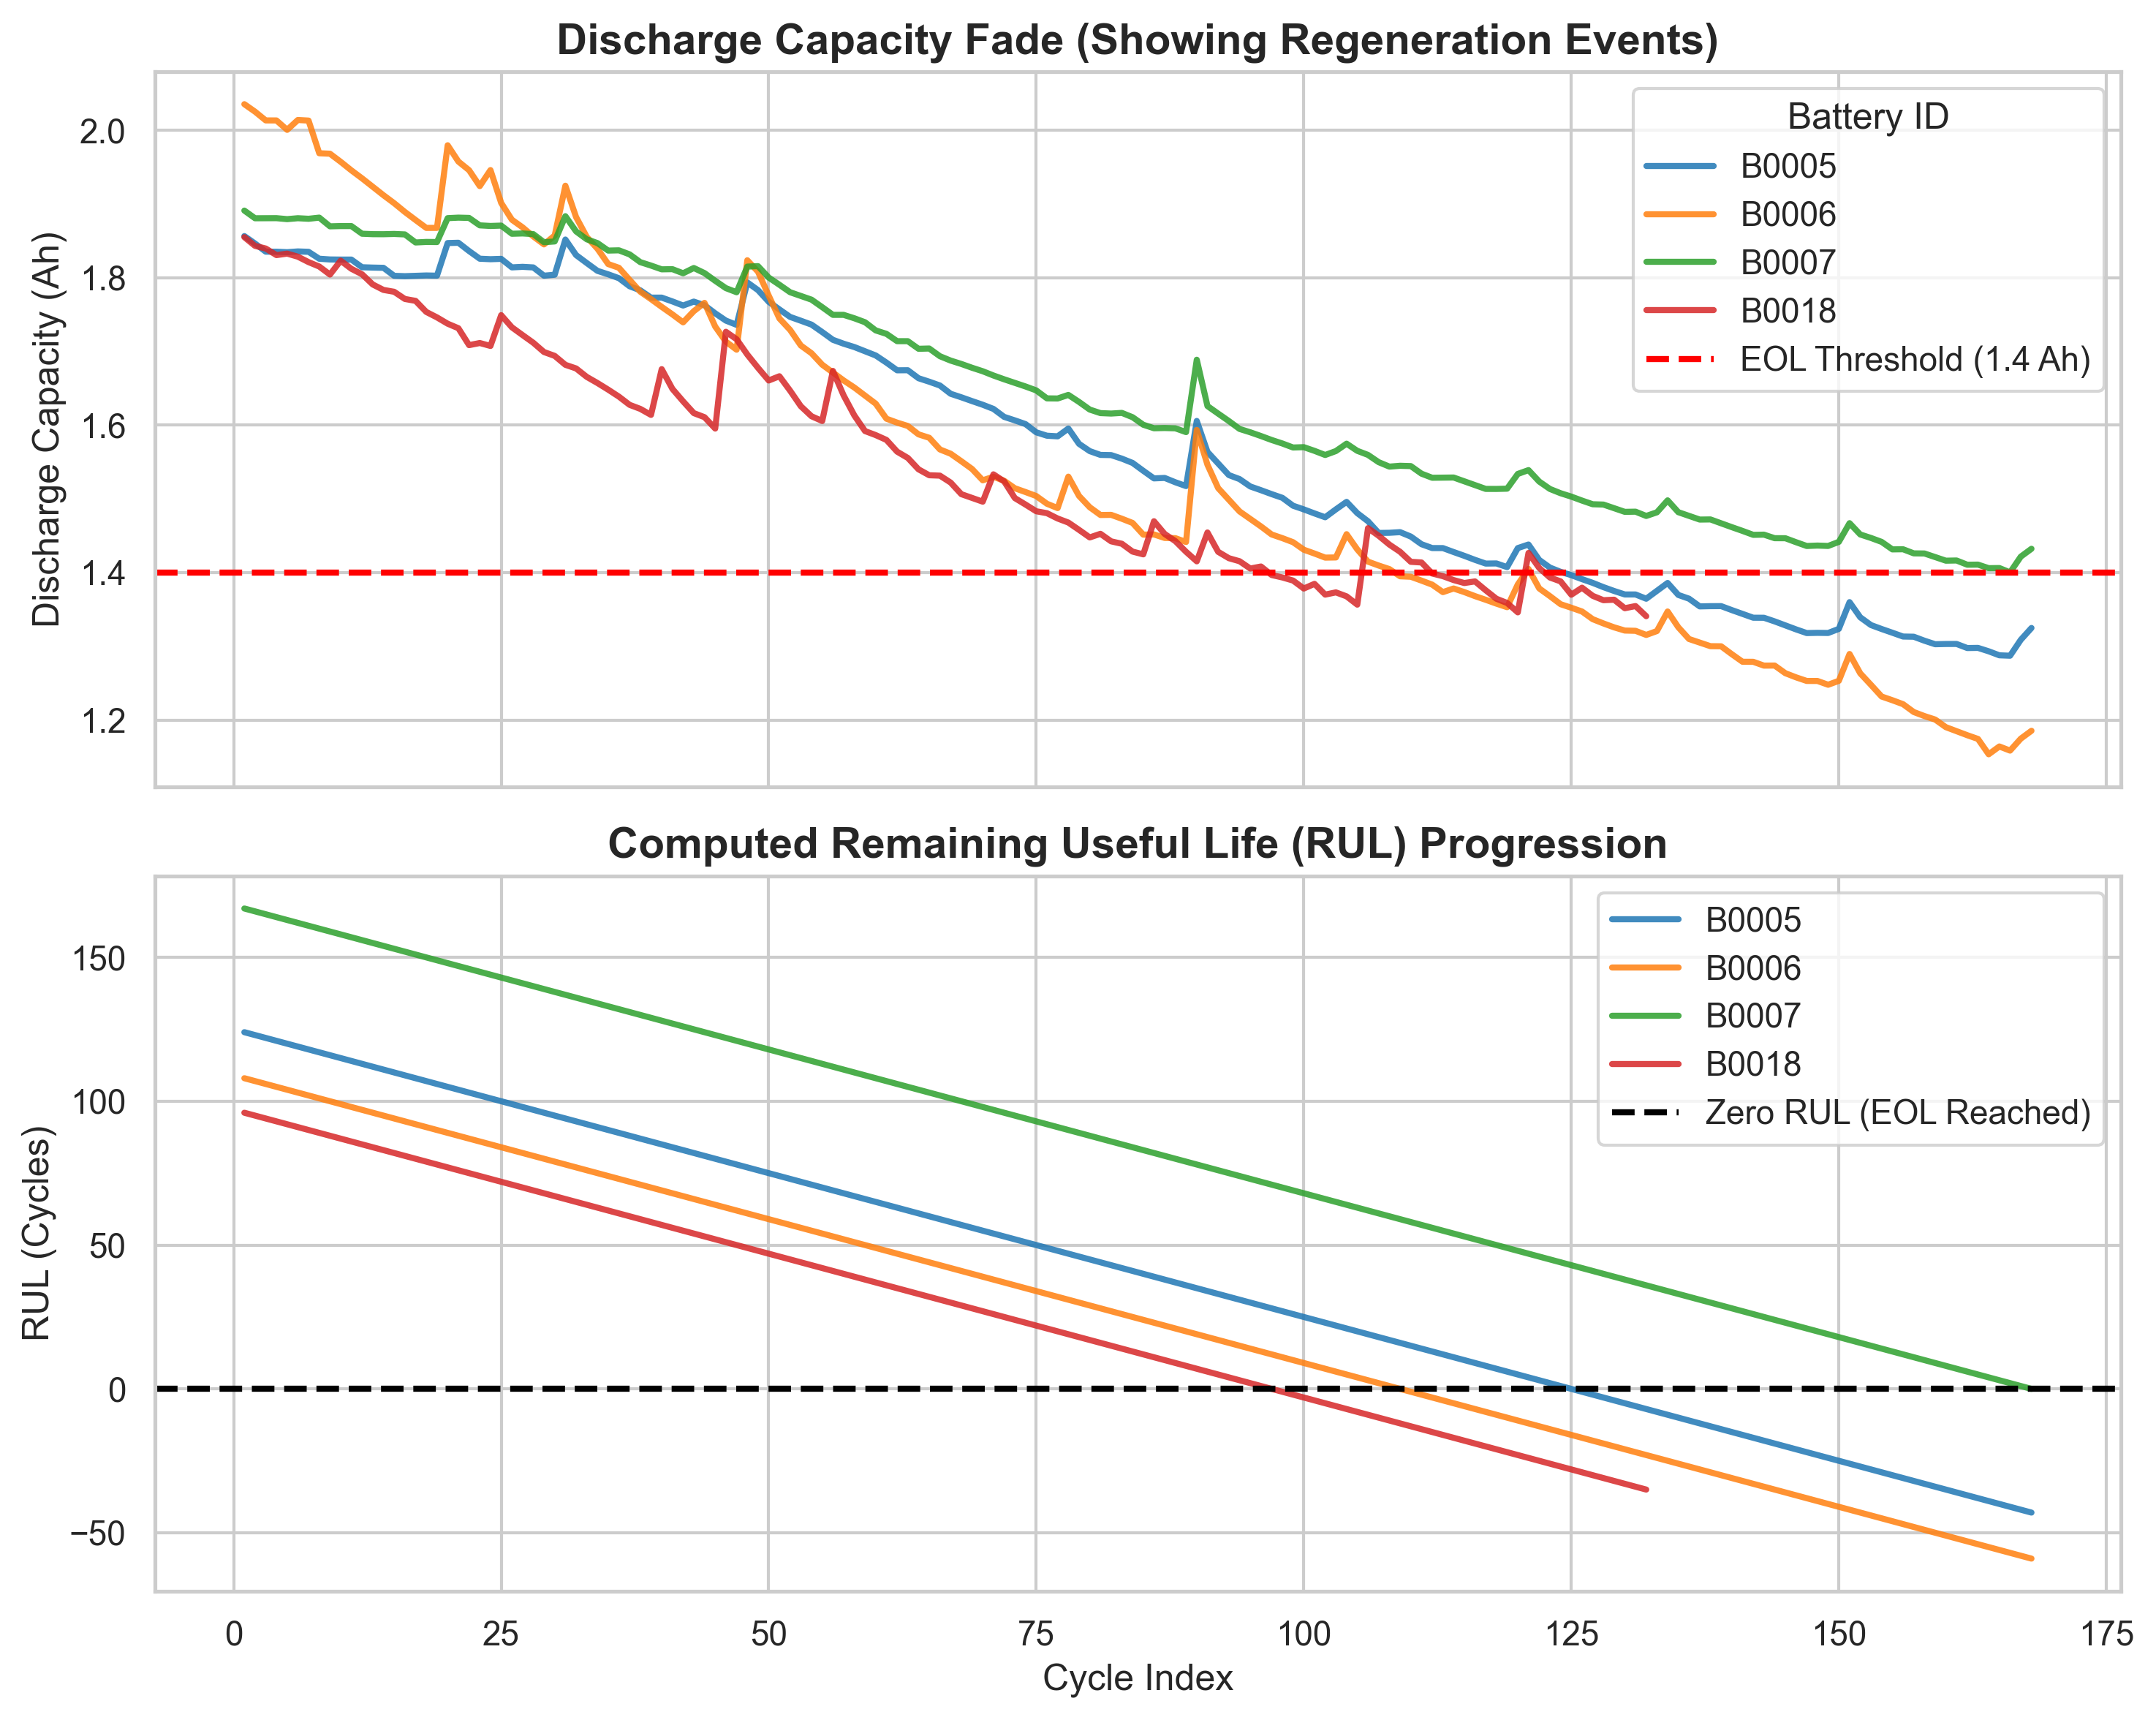

Success! High-resolution dual-plot saved as 'Fig2_Capacity_RUL_Progression.png'


In [18]:
target_batteries = ['B0005', 'B0006', 'B0007', 'B0018']
df_plot = df[df['battery'].isin(target_batteries)].copy()

# 3. Set up the matplotlib figure (2 rows, 1 column, shared X-axis)
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), dpi=300, sharex=True)

# --- TOP PANEL: Discharge Capacity Fade ---
sns.lineplot(
    data=df_plot, 
    x='cycle', 
    y='discharge_capacity', 
    hue='battery', 
    palette='tab10', 
    linewidth=2, 
    alpha=0.85,
    ax=ax1
)
ax1.axhline(y=1.4, color='red', linestyle='--', linewidth=2, label='EOL Threshold (1.4 Ah)')
ax1.set_title("Discharge Capacity Fade (Showing Regeneration Events)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Discharge Capacity (Ah)", fontsize=12)

# Fix Top Legend
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles=handles1, labels=labels1, title='Battery ID', loc='upper right')

# --- BOTTOM PANEL: RUL Progression ---
sns.lineplot(
    data=df_plot, 
    x='cycle', 
    y='RUL', 
    hue='battery', 
    palette='tab10', 
    linewidth=2, 
    alpha=0.85,
    ax=ax2
)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Zero RUL (EOL Reached)')
ax2.set_title("Computed Remaining Useful Life (RUL) Progression", fontsize=14, fontweight='bold')
ax2.set_ylabel("RUL (Cycles)", fontsize=12)
ax2.set_xlabel("Cycle Index", fontsize=12)

# Fix Bottom Legend
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles=handles2, labels=labels2, loc='upper right')

# 4. Final Layout Adjustments and Save
plt.tight_layout()
plt.savefig("Fig2_Capacity_RUL_Progression.png", format='png', dpi=300, bbox_inches='tight')
plt.show()

print("Success! High-resolution dual-plot saved as 'Fig2_Capacity_RUL_Progression.png'")

In [4]:

print(f"Original dataset shape: {df.shape}")

# Clean negative RUL values
df = df[df['RUL'] >= 0].copy()

print(f"Cleaned dataset shape (RUL >= 0): {df.shape}")

# Display the first few rows
display(df.head())

Original dataset shape: (636, 11)
Cleaned dataset shape (RUL >= 0): (499, 11)


,battery,cycle,discharge_capacity,avg_voltage,end_voltage,discharge_time,cv_charge_time,Re,Rct,SOH,RUL
0,B0005,1,1.856487,3.529829,3.277170,3690.234,7051.265,0.044669,0.069456,1.000000,124
1,B0005,2,1.846327,3.537320,3.300245,3672.344,7398.594,0.044669,0.069456,0.994527,123
2,B0005,3,1.835349,3.543737,3.327451,3651.641,7369.875,0.044669,0.069456,0.988614,122
3,B0005,4,1.835263,3.543666,3.314182,3631.563,7303.422,0.044669,0.069456,0.988567,121
4,B0005,5,1.834646,3.542343,3.305497,3629.172,7390.719,0.044669,0.069456,0.988235,120


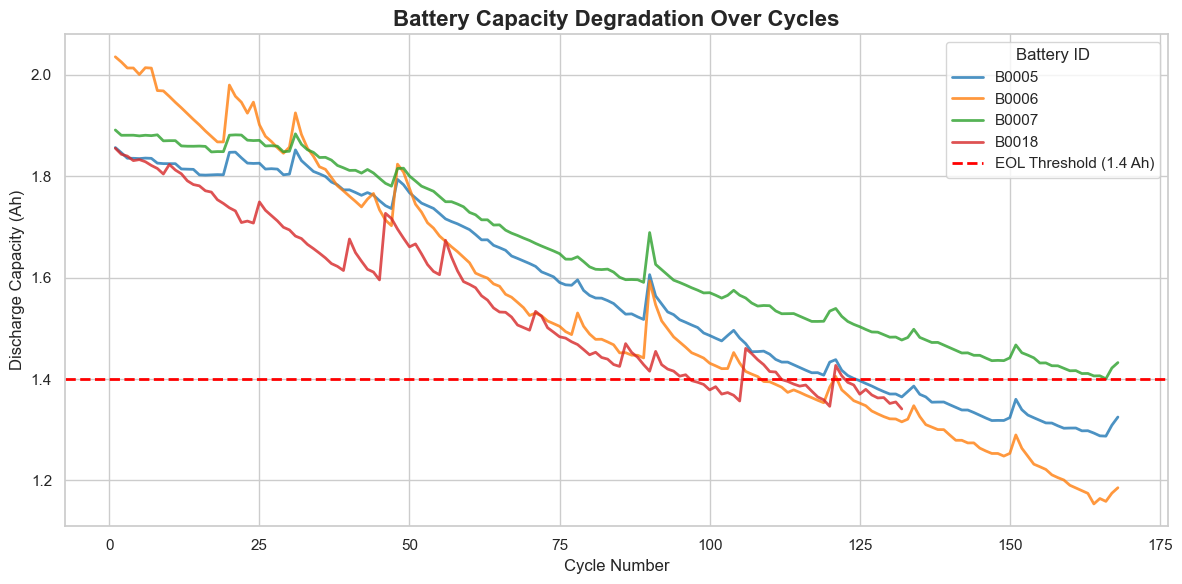

In [19]:
plt.figure(figsize=(12,6))

# 4. Plot discharge capacity over cycles for each battery automatically
# The 'hue' parameter tells seaborn to use a different color for each battery ID
sns.lineplot(
    data=df, 
    x='cycle', 
    y='discharge_capacity', 
    hue='battery', 
    palette='tab10',  # Clean, distinct colors
    linewidth=2,
    alpha=0.8
)

# 5. Add an End-of-Life (EOL) threshold line (1.4 Ah is the NASA standard)
plt.axhline(y=1.4, color='red', linestyle='--', linewidth=2, label='EOL Threshold (1.4 Ah)')

# 6. Customize Labels and Title
plt.title('Battery Capacity Degradation Over Cycles', fontsize=16, fontweight='bold')
plt.xlabel('Cycle Number', fontsize=12)
plt.ylabel('Discharge Capacity (Ah)', fontsize=12)

# 7. Refine the legend
# We combine the seaborn legend (batteries) with the matplotlib legend (EOL line)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Battery ID', fontsize=11, title_fontsize=12)

# 8. Show the plot
plt.tight_layout()
plt.show()

In [7]:
# Select features (Dropping 'battery' as it's a string, and 'cycle' to force the model to learn physics)
features = ['discharge_capacity', 'avg_voltage', 'end_voltage', 
            'discharge_time', 'cv_charge_time']
target = 'RUL'

X = df[features]
y = df[target]

# Sequential Split (No Shuffling for time-series data)
# Let's use the first 80% of cycles to train, and predict the last 20%
train_size = int(len(X) * 0.80)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Scale the features (Critical for Ridge, SVR, and LSTM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training on {len(X_train)} cycles, Testing on {len(X_test)} cycles.")

Training on 399 cycles, Testing on 100 cycles.


Training on batteries: <StringArray>
['B0005', 'B0006', 'B0007']
Length: 3, dtype: str
Testing entirely on unseen battery: B0018
Starting Battery RUL Training with LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 10.4055	validation's rmse: 12.6131
[200]	training's rmse: 6.55083	validation's rmse: 11.5181
Early stopping, best iteration is:
[194]	training's rmse: 6.60434	validation's rmse: 11.4969


<Figure size 800x500 with 0 Axes>

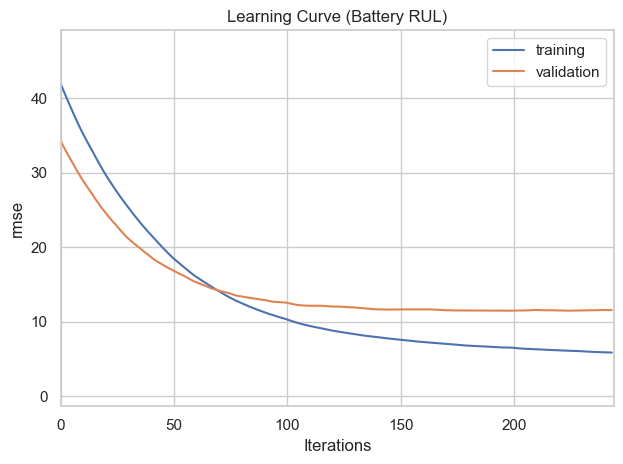


--- Final Evaluation ---
RMSE:             11.50 cycles
MAE:              8.52 cycles
Relative Error:   33.44%
R²:               0.8314


<Figure size 1000x600 with 0 Axes>

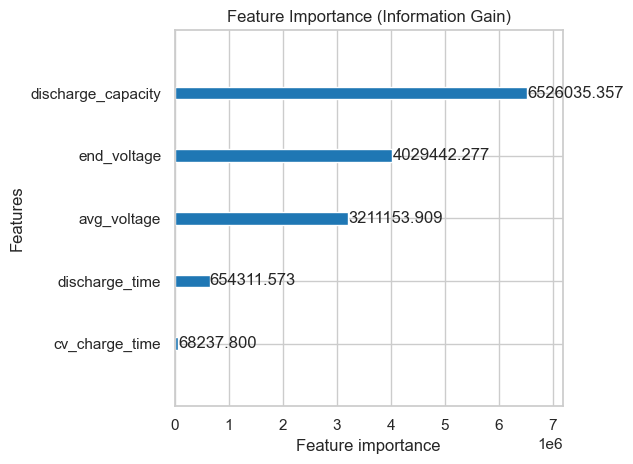

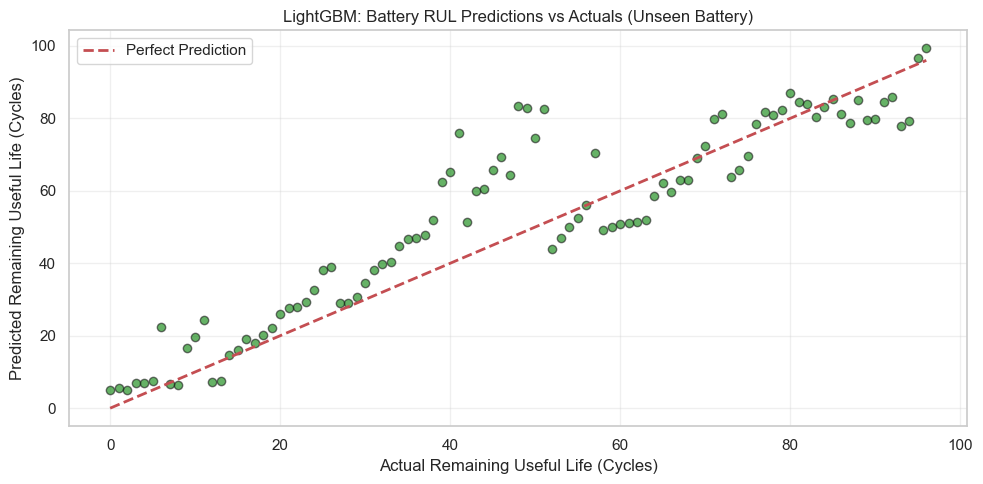


Model successfully saved to battery_rul_lightgbm.pkl!


In [20]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_error, 
    r2_score, 
    mean_absolute_error, 
    mean_absolute_percentage_error
)
from sklearn.model_selection import train_test_split
import joblib   

df = df[df['RUL'] >= 0].copy()

# CHOOSE YOUR TEST BATTERY (e.g., B0018)
test_battery_id = 'B0018'

# Split the data based on the battery ID, not randomly
train_df = df[df['battery'] != test_battery_id]
test_df = df[df['battery'] == test_battery_id]

print(f"Training on batteries: {train_df['battery'].unique()}")
print(f"Testing entirely on unseen battery: {test_battery_id}")

# Now drop the non-physics columns (including 'battery') for ML
X_train = train_df.drop(columns=['RUL', 'battery', 'cycle','Re', 'Rct', 'SOH'], errors='ignore')
y_train = train_df['RUL']

X_test = test_df.drop(columns=['RUL', 'battery', 'cycle','Re', 'Rct', 'SOH'], errors='ignore')
y_test = test_df['RUL']

# Create LightGBM Datasets
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# --- 2. Hyperparameters for Battery Data ---
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,      # Slightly faster than the engine model
    'num_leaves': 31,           # Standard complexity
    'max_depth': -1,            # Let the tree grow deep (batteries have less noise)
    'feature_fraction': 0.9,    # Use 90% of features
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# --- 3. Training ---
evals_result = {}  # Store metrics history

print("Starting Battery RUL Training with LightGBM...")
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    valid_names=['training', 'validation'],
    num_boost_round=5000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # Stop if no improvement for 50 rounds
        lgb.log_evaluation(period=100),
        lgb.record_evaluation(evals_result)     # Record history
    ]
)

# --- 4. Plot Learning Curve ---
try:
    plt.figure(figsize=(8, 5))
    lgb.plot_metric(evals_result, metric='rmse')
    plt.title("Learning Curve (Battery RUL)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot error: {e}")

# --- 5. Final Evaluation (Corrected) ---
print("\n--- Final Evaluation ---")
y_pred = model.predict(X_test)
y_pred = np.maximum(y_pred, 0) # RUL cannot be negative

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# --- SAFE RELATIVE ERROR (MAPE) ---
# Only calculate percentage error where actual RUL is greater than 0
mask = y_test > 0
safe_mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print(f"RMSE:             {rmse:.2f} cycles")
print(f"MAE:              {mae:.2f} cycles")
print(f"Relative Error:   {safe_mape:.2f}%")
print(f"R²:               {r2:.4f}")
# --- 6. Feature Importance ---
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=10, importance_type='gain', color='#1f77b4')
plt.title("Feature Importance (Information Gain)")
plt.tight_layout()
plt.show()

# --- 7. Prediction vs Actual Plot ---
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='green', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Remaining Useful Life (Cycles)")
plt.ylabel("Predicted Remaining Useful Life (Cycles)")
plt.title("LightGBM: Battery RUL Predictions vs Actuals (Unseen Battery)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8. SAVE THE MODEL ---
# Once you are happy with the results, save it for the ESP32 Pipeline
model_filename = "battery_rul_lightgbm.pkl"
joblib.dump(model, model_filename)
print(f"\nModel successfully saved to {model_filename}!")

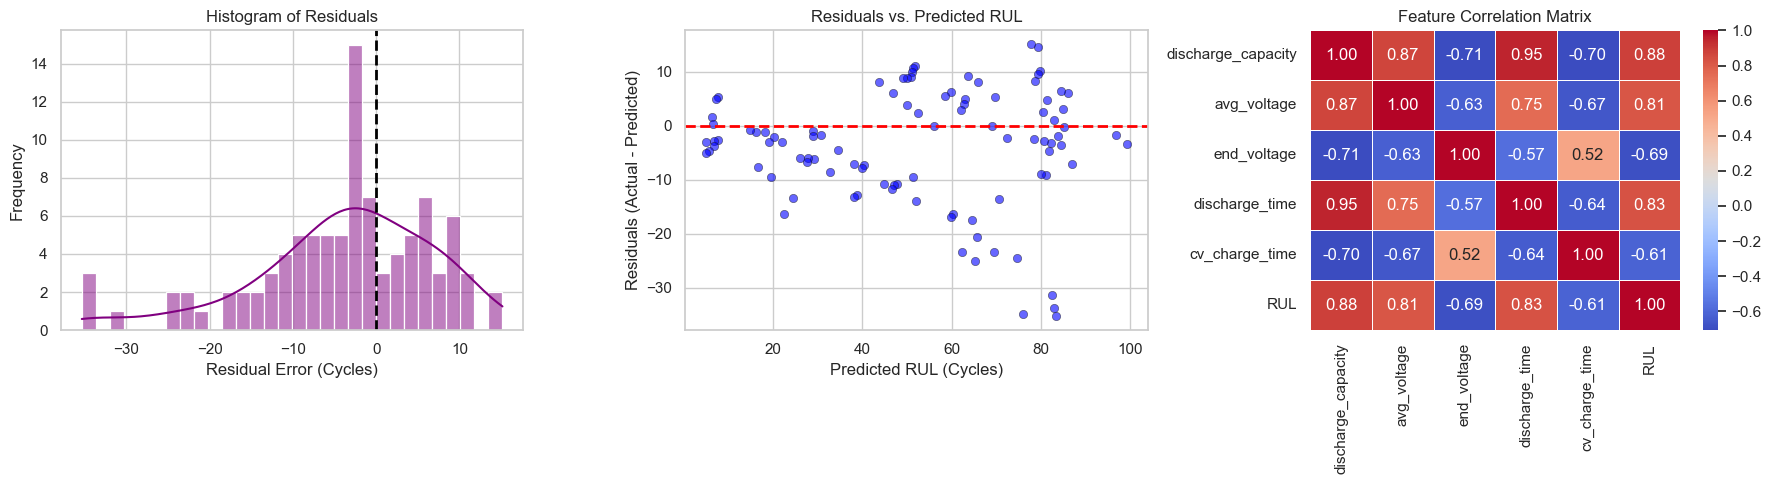

In [9]:
import seaborn as sns

# --- 8. Advanced Diagnostics Plots ---

# Calculate Residuals (Error = Actual - Predicted)
residuals = y_test - y_pred

# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Histogram of Residuals
sns.histplot(residuals, kde=True, ax=axes[0], color='purple', bins=30)
axes[0].axvline(0, color='black', linestyle='--', lw=2)
axes[0].set_title('Histogram of Residuals')
axes[0].set_xlabel('Residual Error (Cycles)')
axes[0].set_ylabel('Frequency')

# Plot B: Residuals vs Predicted Values
sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], alpha=0.6, color='blue', edgecolor='k')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted RUL')
axes[1].set_xlabel('Predicted RUL (Cycles)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

# Plot C: Correlation Heatmap
# Compute correlation matrix for the dataframe (excluding string columns if any exist)
corr_matrix = df.drop(columns=['battery', 'cycle', 'Re', 'Rct', 'SOH'], errors='ignore').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, cbar=True, ax=axes[2], square=False)
axes[2].set_title('Feature Correlation Matrix')

# Adjust layout and show
plt.tight_layout()
plt.show()


Starting Battery RUL Training with XGBoost...
[0]	validation_0-rmse:41.88366	validation_1-rmse:34.34110
[100]	validation_0-rmse:7.83388	validation_1-rmse:11.78508
[200]	validation_0-rmse:2.68037	validation_1-rmse:10.27452
[300]	validation_0-rmse:1.56376	validation_1-rmse:10.11618
[400]	validation_0-rmse:1.14842	validation_1-rmse:10.07436
[500]	validation_0-rmse:0.87855	validation_1-rmse:10.03378
[600]	validation_0-rmse:0.69364	validation_1-rmse:10.01180
[700]	validation_0-rmse:0.55270	validation_1-rmse:10.00519
[704]	validation_0-rmse:0.54760	validation_1-rmse:10.00443

--- Final XGBoost Evaluation ---
RMSE:             10.00 cycles
MAE:              6.77 cycles
Relative Error:   25.70%
R²:               0.8723


<Figure size 1000x500 with 0 Axes>

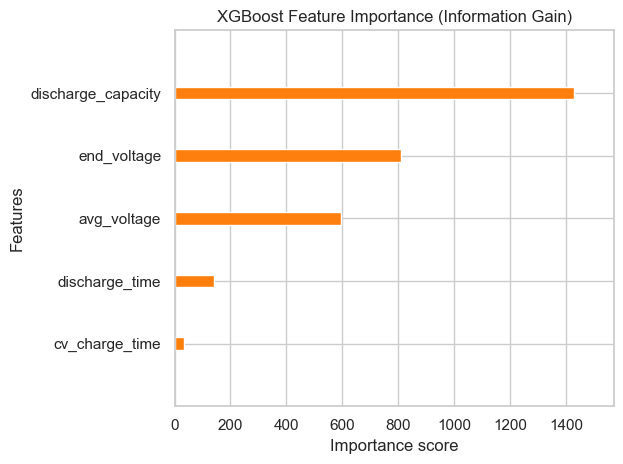

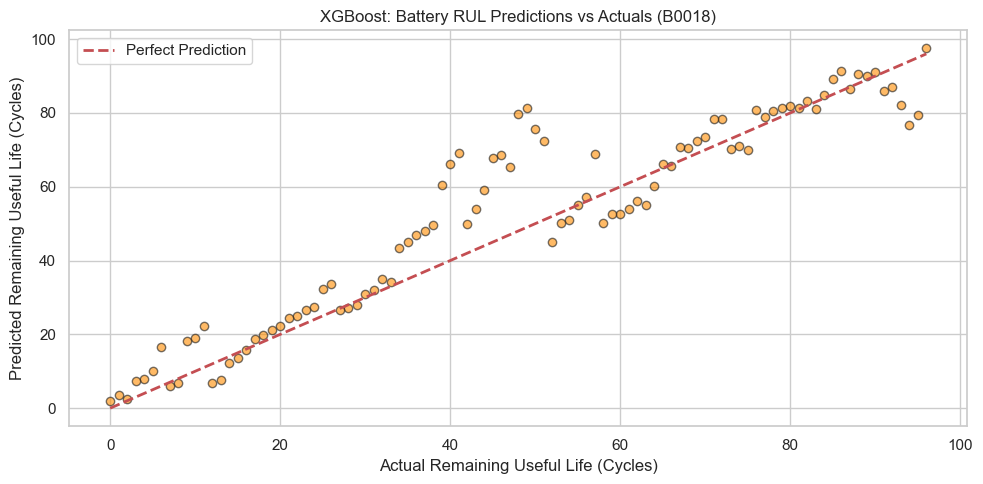

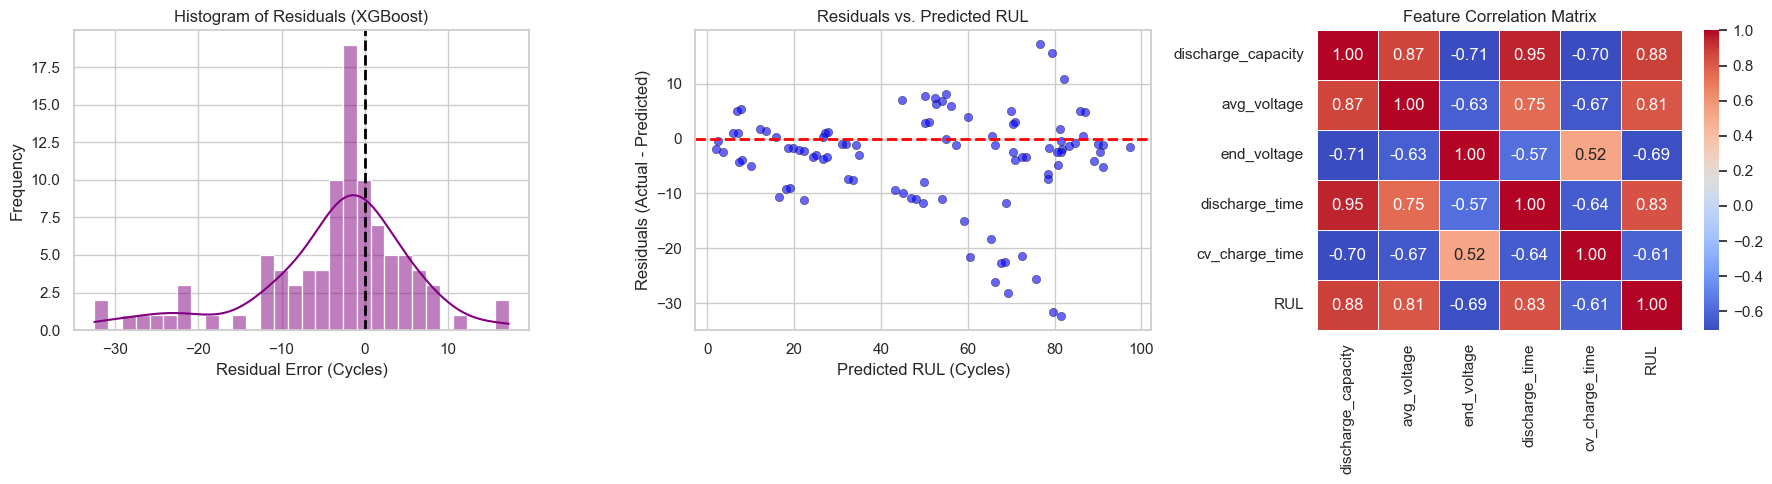


XGBoost Model successfully saved to battery_rul_xgboost.pkl!


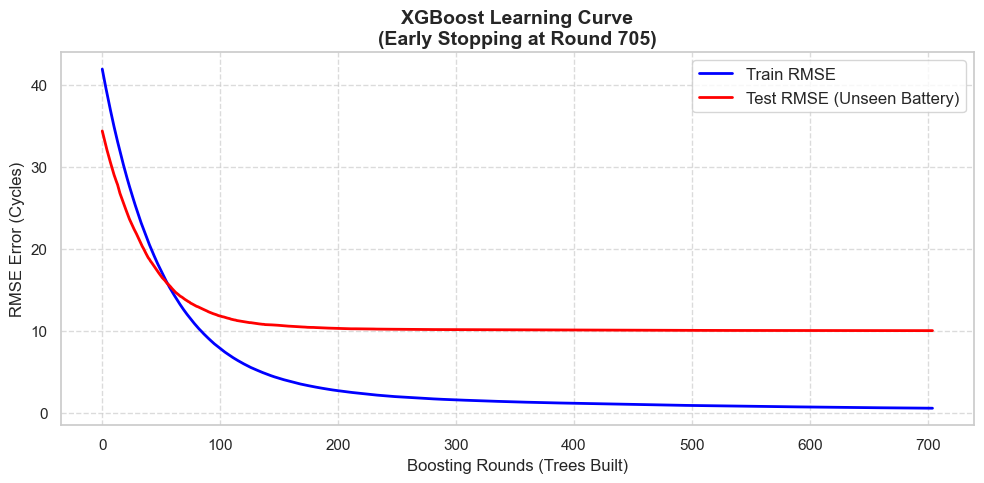

In [10]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_error, 
    r2_score, 
    mean_absolute_error
)
import joblib


print("\nStarting Battery RUL Training with XGBoost...")

# Hyperparameters tailored for Battery Degradation
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=5000,           # High number of trees
    learning_rate=0.02,          # Slow learning rate to capture smooth curves
    max_depth=6,                 # Standard depth
    subsample=0.8,               # Prevent overfitting by bagging 80% of data
    colsample_bytree=0.9,        # Use 90% of features per tree
    random_state=42,
    early_stopping_rounds=50,    # Stop if validation score doesn't improve for 50 rounds
    eval_metric='rmse'
)

# Train the model
eval_set = [(X_train, y_train), (X_test, y_test)]
xgb_model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=100  # Print progress every 100 rounds
)


# --- 3. Final Evaluation Metrics ---
print("\n--- Final XGBoost Evaluation ---")
y_pred = xgb_model.predict(X_test)
y_pred = np.maximum(y_pred, 0) # RUL cannot be negative

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# SAFE RELATIVE ERROR (MAPE)
mask = y_test > 0
safe_mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print(f"RMSE:             {rmse:.2f} cycles")
print(f"MAE:              {mae:.2f} cycles")
print(f"Relative Error:   {safe_mape:.2f}%")
print(f"R²:               {r2:.4f}")


# --- 4. Plotting & Diagnostics ---
sns.set_theme(style="whitegrid")

# Plot A: Feature Importance
plt.figure(figsize=(10, 5))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='gain', show_values=False, color='#ff7f0e')
plt.title("XGBoost Feature Importance (Information Gain)")
plt.tight_layout()
plt.show()

# Plot B: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkorange', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Remaining Useful Life (Cycles)")
plt.ylabel("Predicted Remaining Useful Life (Cycles)")
plt.title(f"XGBoost: Battery RUL Predictions vs Actuals ({test_battery_id})")
plt.legend()
plt.tight_layout()
plt.show()

# --- Advanced Diagnostics Subplots ---
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot C: Histogram of Residuals
sns.histplot(residuals, kde=True, ax=axes[0], color='purple', bins=30)
axes[0].axvline(0, color='black', linestyle='--', lw=2)
axes[0].set_title('Histogram of Residuals (XGBoost)')
axes[0].set_xlabel('Residual Error (Cycles)')
axes[0].set_ylabel('Frequency')

# Plot D: Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], alpha=0.6, color='blue', edgecolor='k')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted RUL')
axes[1].set_xlabel('Predicted RUL (Cycles)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

# Plot E: Correlation Heatmap
corr_matrix = df.drop(columns=['battery', 'cycle','Re', 'Rct', 'SOH'], errors='ignore').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, cbar=True, ax=axes[2], square=False)
axes[2].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()


# --- 5. SAVE THE MODEL ---
model_filename = "battery_rul_xgboost.pkl"
joblib.dump(xgb_model, model_filename)
print(f"\nXGBoost Model successfully saved to {model_filename}!")

results = xgb_model.evals_result()

# Count the number of boosting rounds (epochs) it actually completed
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

# Create the Learning Curve plot
plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE', color='blue', linewidth=2)
plt.plot(x_axis, results['validation_1']['rmse'], label='Test RMSE (Unseen Battery)', color='red', linewidth=2)

# Styling
plt.xlabel('Boosting Rounds (Trees Built)', fontsize=12)
plt.ylabel('RMSE Error (Cycles)', fontsize=12)
plt.title(f'XGBoost Learning Curve\n(Early Stopping at Round {epochs})', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Training on batteries: <StringArray>
['B0005', 'B0006', 'B0007']
Length: 3, dtype: str
Testing entirely on unseen battery: B0018

Starting Battery RUL Training with SVR...

--- Final SVR Evaluation ---
RMSE:             12.99 cycles
MAE:              8.78 cycles
Relative Error:   31.18%
R²:               0.7847


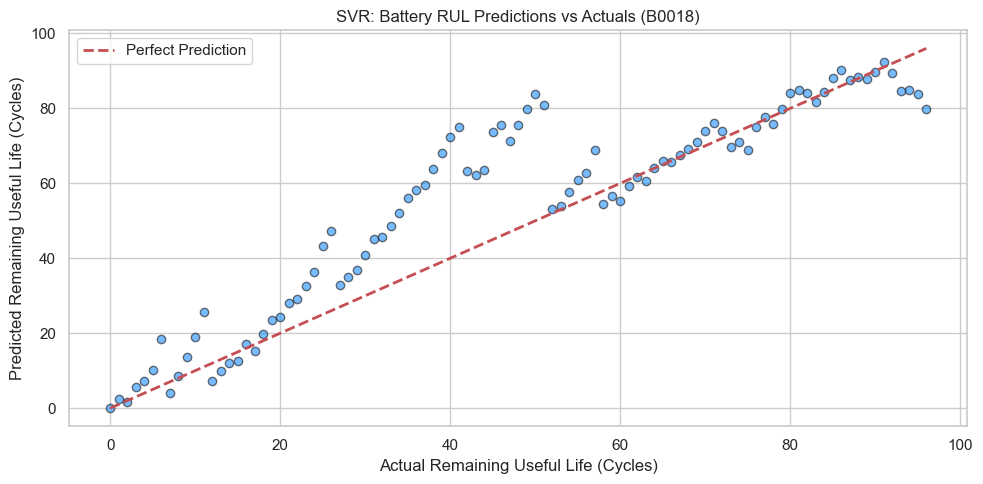

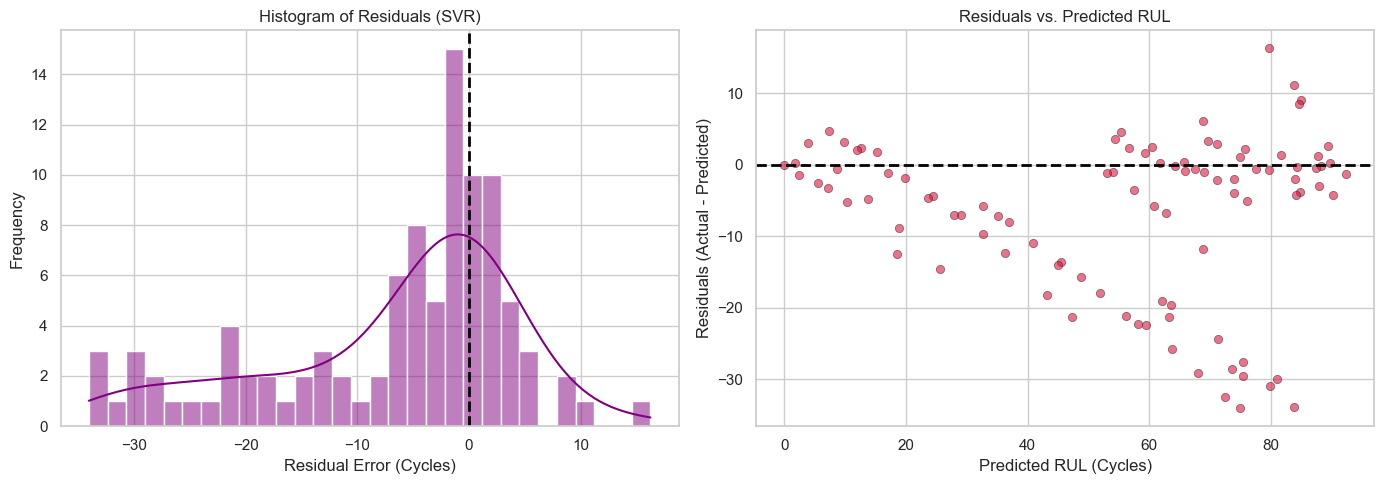


SVR Model and Scaler successfully saved!
Calculating Permutation Importance (this may take a few seconds)...
Calculating Learning Curve...


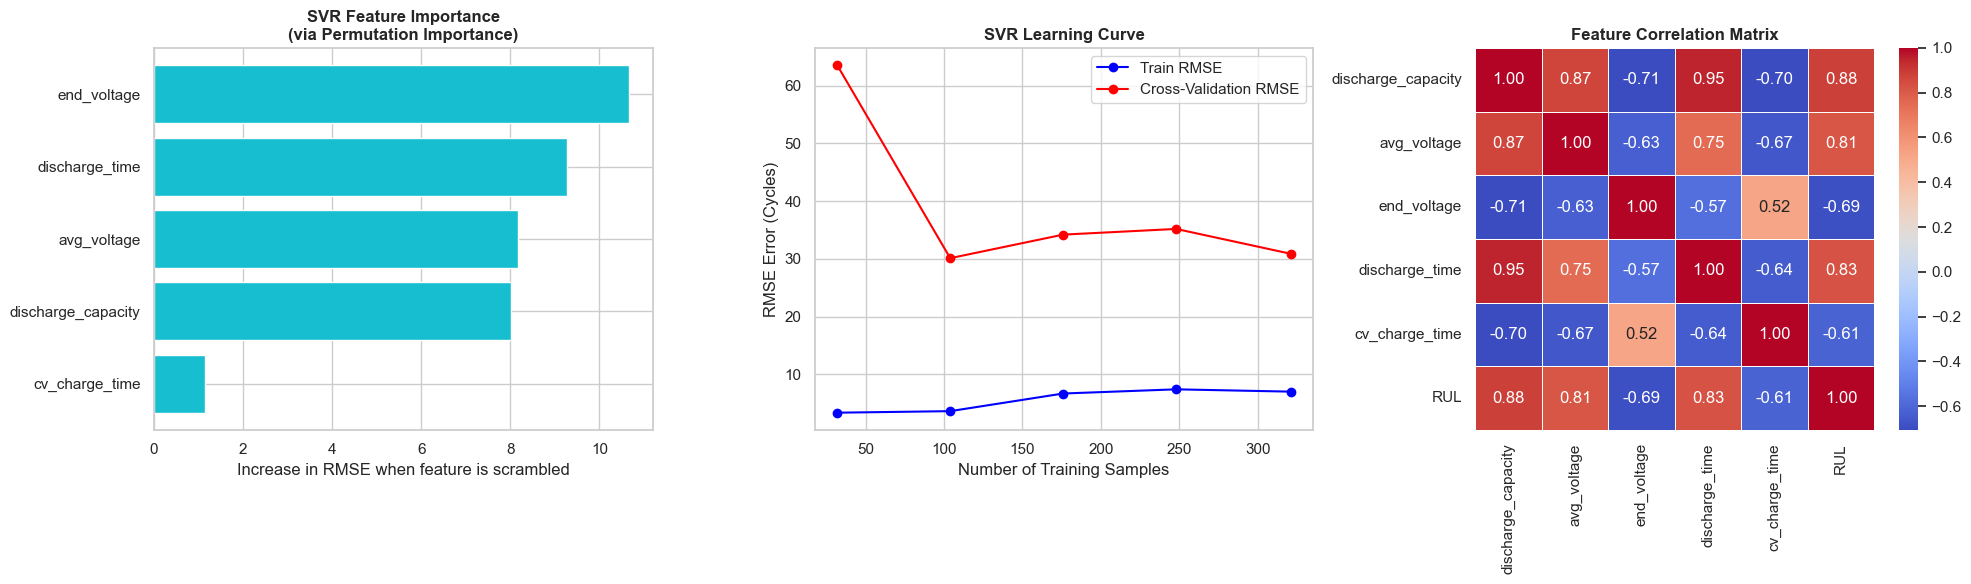

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve
import joblib


# CHOOSE YOUR TEST BATTERY (e.g., B0018)
test_battery_id = 'B0018'

train_df = df[df['battery'] != test_battery_id]
test_df = df[df['battery'] == test_battery_id]

print(f"Training on batteries: {train_df['battery'].unique()}")
print(f"Testing entirely on unseen battery: {test_battery_id}")

X_train = train_df.drop(columns=['RUL', 'battery', 'cycle','Re', 'Rct', 'SOH'], errors='ignore')
y_train = train_df['RUL']

X_test = test_df.drop(columns=['RUL', 'battery', 'cycle','Re', 'Rct', 'SOH'], errors='ignore')
y_test = test_df['RUL']


# --- 2. Feature Scaling (CRITICAL FOR SVR) ---
# SVR will fail to converge or perform terribly if features aren't scaled
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- 3. Build and Train High-Performance SVR ---
print("\nStarting Battery RUL Training with SVR...")

# Hyperparameters tailored for Battery Degradation
# C=100 allows some flexibility, epsilon=1.0 ignores errors within 1 cycle
svr_model = SVR(
    kernel='rbf',       # Radial Basis Function (handles non-linear curves)
    C=100.0,            # Regularization parameter
    gamma='scale',      # Kernel coefficient
    epsilon=1.0         # Epsilon-tube (no penalty for errors under 1 cycle)
)

# Train the model (SVR doesn't have verbose output or early stopping like trees)
svr_model.fit(X_train_scaled, y_train)


# --- 4. Final Evaluation Metrics ---
print("\n--- Final SVR Evaluation ---")
y_pred = svr_model.predict(X_test_scaled) # Remember to predict on SCALED data
y_pred = np.maximum(y_pred, 0)            # RUL cannot be negative

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# SAFE RELATIVE ERROR (MAPE)
mask = y_test > 0
safe_mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print(f"RMSE:             {rmse:.2f} cycles")
print(f"MAE:              {mae:.2f} cycles")
print(f"Relative Error:   {safe_mape:.2f}%")
print(f"R²:               {r2:.4f}")


# --- 5. Plotting & Diagnostics ---
sns.set_theme(style="whitegrid")

# Plot A: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Remaining Useful Life (Cycles)")
plt.ylabel("Predicted Remaining Useful Life (Cycles)")
plt.title(f"SVR: Battery RUL Predictions vs Actuals ({test_battery_id})")
plt.legend()
plt.tight_layout()
plt.show()

# --- Advanced Diagnostics Subplots ---
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot B: Histogram of Residuals
sns.histplot(residuals, kde=True, ax=axes[0], color='purple', bins=30)
axes[0].axvline(0, color='black', linestyle='--', lw=2)
axes[0].set_title('Histogram of Residuals (SVR)')
axes[0].set_xlabel('Residual Error (Cycles)')
axes[0].set_ylabel('Frequency')

# Plot C: Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], alpha=0.6, color='crimson', edgecolor='k')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted RUL')
axes[1].set_xlabel('Predicted RUL (Cycles)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()


# --- 6. SAVE THE MODEL AND SCALER ---
# For SVR, you MUST save both the model AND the scaler, because real-time ESP32 data must be scaled!
joblib.dump(svr_model, "battery_rul_svr_model.pkl")
joblib.dump(scaler, "battery_rul_svr_scaler.pkl")
print("\nSVR Model and Scaler successfully saved!")

# --- 6. Advanced SVR Plots (Feature Importance, Learning Curve, Heatmap) ---

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---------------------------------------------------------
# Plot A: Permutation Feature Importance (SVR Workaround)
# ---------------------------------------------------------
print("Calculating Permutation Importance (this may take a few seconds)...")
# We use negative RMSE, so larger drops mean the feature was more important
perm_importance = permutation_importance(
    svr_model, X_test_scaled, y_test, 
    n_repeats=10, random_state=42, scoring='neg_root_mean_squared_error'
)

# Sort the features by importance
sorted_idx = perm_importance.importances_mean.argsort()
feature_names = X_test.columns[sorted_idx]
importances = perm_importance.importances_mean[sorted_idx]

axes[0].barh(feature_names, importances, color='#17becf')
axes[0].set_title('SVR Feature Importance\n(via Permutation Importance)', fontweight='bold')
axes[0].set_xlabel('Increase in RMSE when feature is scrambled')


# ---------------------------------------------------------
# Plot B: SVR Learning Curve
# ---------------------------------------------------------
print("Calculating Learning Curve...")
# Train the SVR on 10%, 30%, 50%, 70%, and 100% of the training data
train_sizes, train_scores, test_scores = learning_curve(
    svr_model, X_train_scaled, y_train, cv=5, 
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Convert negative RMSE back to positive RMSE
train_rmse_mean = -np.mean(train_scores, axis=1)
test_rmse_mean = -np.mean(test_scores, axis=1)

axes[1].plot(train_sizes, train_rmse_mean, 'o-', color='blue', label='Train RMSE')
axes[1].plot(train_sizes, test_rmse_mean, 'o-', color='red', label='Cross-Validation RMSE')
axes[1].set_title('SVR Learning Curve', fontweight='bold')
axes[1].set_xlabel('Number of Training Samples')
axes[1].set_ylabel('RMSE Error (Cycles)')
axes[1].legend(loc='upper right')


# ---------------------------------------------------------
# Plot C: Correlation Heatmap
# ---------------------------------------------------------
# Compute correlation matrix for the dataframe (excluding string columns)
corr_matrix = df.drop(columns=['battery', 'cycle','Re', 'Rct', 'SOH'], errors='ignore').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, cbar=True, ax=axes[2], square=False)
axes[2].set_title('Feature Correlation Matrix', fontweight='bold')


plt.tight_layout()
plt.show()

Training on batteries: <StringArray>
['B0005', 'B0006', 'B0007']
Length: 3, dtype: str
Testing entirely on unseen battery: B0018

Starting Battery RUL Training with Random Forest...

--- Final Random Forest Evaluation ---
RMSE:             10.75 cycles
MAE:              7.82 cycles
Relative Error:   37.44%
R²:               0.8525


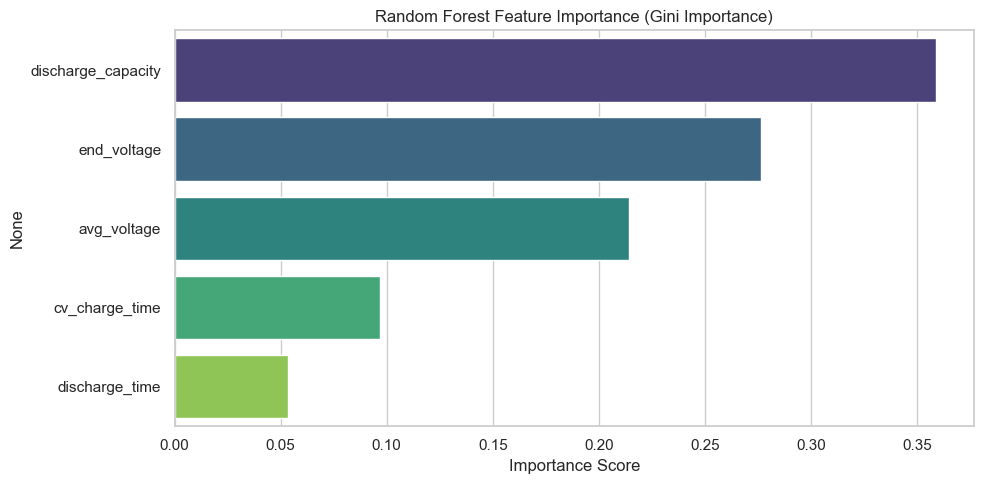

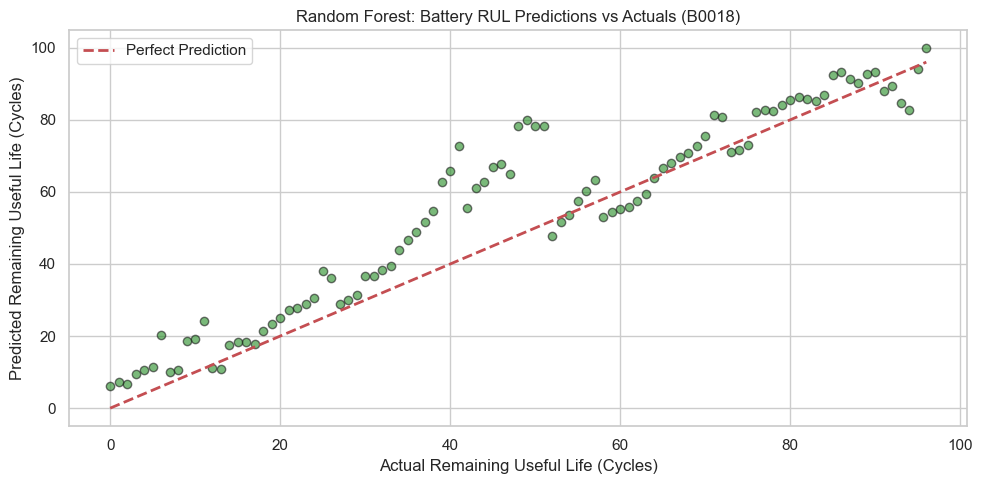

Calculating Learning Curve (This takes a moment for Random Forest)...


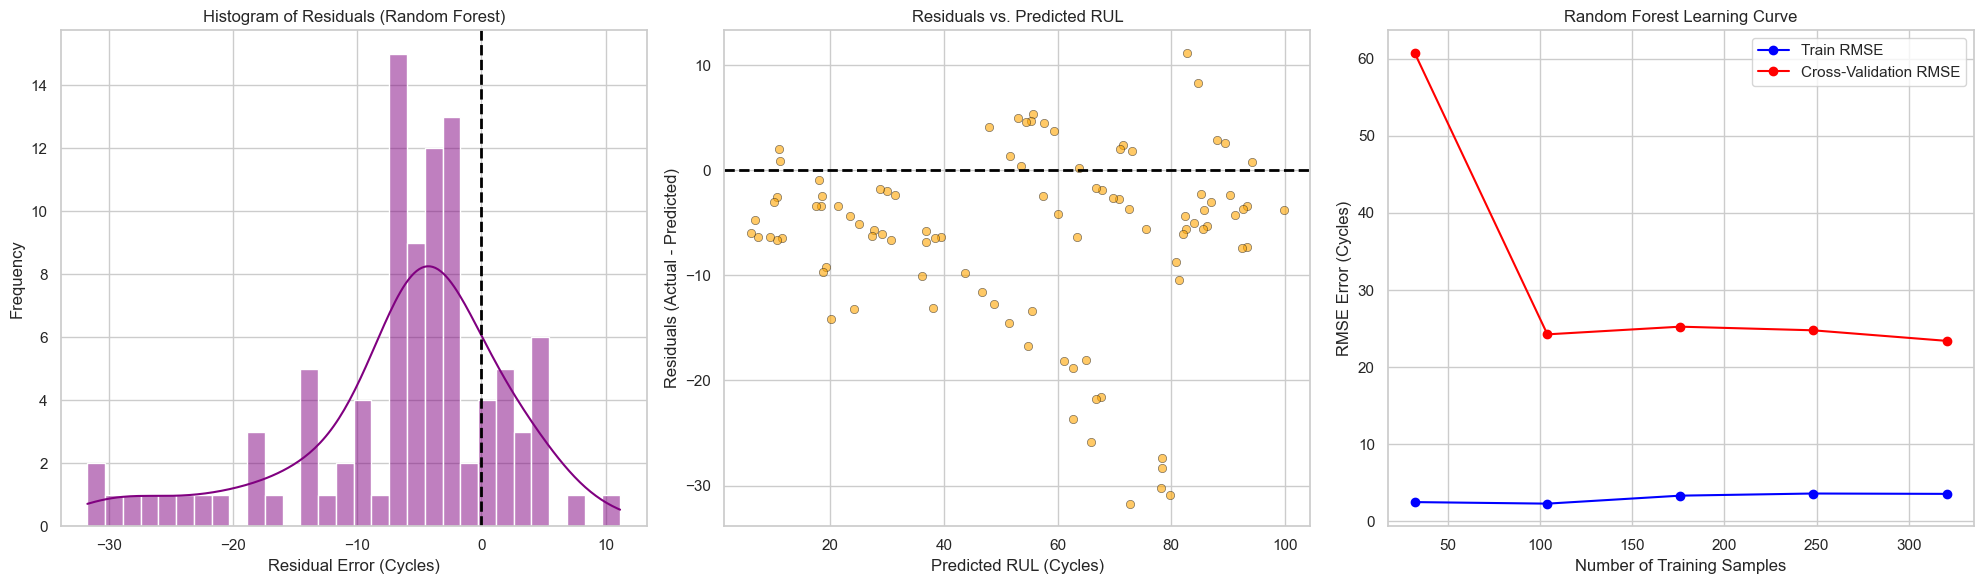


Random Forest Model successfully saved to battery_rul_randomforest.pkl!


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import learning_curve
import joblib


# CHOOSE YOUR TEST BATTERY (e.g., B0018)
test_battery_id = 'B0018'

train_df = df[df['battery'] != test_battery_id]
test_df = df[df['battery'] == test_battery_id]

print(f"Training on batteries: {train_df['battery'].unique()}")
print(f"Testing entirely on unseen battery: {test_battery_id}")

X_train = train_df.drop(columns=['RUL', 'battery', 'cycle','Re', 'Rct', 'SOH'], errors='ignore')
y_train = train_df['RUL']

X_test = test_df.drop(columns=['RUL', 'battery', 'cycle','Re', 'Rct', 'SOH'], errors='ignore')
y_test = test_df['RUL']


# --- 2. Build and Train Random Forest ---
print("\nStarting Battery RUL Training with Random Forest...")

# Hyperparameters tailored for continuous degradation data
rf_model = RandomForestRegressor(
    n_estimators=500,        # Number of trees in the forest
    max_depth=10,            # Limit depth to prevent overfitting on noisy data
    min_samples_split=5,     # Require 5 samples to split a node
    max_features='sqrt',     # Use a subset of features for each tree to increase robustness
    random_state=42,
    n_jobs=-1                # Use all CPU cores for faster training
)

rf_model.fit(X_train, y_train)


# --- 3. Final Evaluation Metrics ---
print("\n--- Final Random Forest Evaluation ---")
y_pred = rf_model.predict(X_test)
y_pred = np.maximum(y_pred, 0) # RUL cannot be negative

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# SAFE RELATIVE ERROR (MAPE)
mask = y_test > 0
safe_mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print(f"RMSE:             {rmse:.2f} cycles")
print(f"MAE:              {mae:.2f} cycles")
print(f"Relative Error:   {safe_mape:.2f}%")
print(f"R²:               {r2:.4f}")


# --- 4. Feature Importance & Actual vs Predicted ---
sns.set_theme(style="whitegrid")

# Plot A: Feature Importance (Native to Random Forest)
plt.figure(figsize=(10, 5))
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=feature_importances.values[:10], y=feature_importances.index[:10], palette='viridis')
plt.title("Random Forest Feature Importance (Gini Importance)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Plot B: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='forestgreen', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Remaining Useful Life (Cycles)")
plt.ylabel("Predicted Remaining Useful Life (Cycles)")
plt.title(f"Random Forest: Battery RUL Predictions vs Actuals ({test_battery_id})")
plt.legend()
plt.tight_layout()
plt.show()


# --- 5. Advanced Diagnostics (Residuals, Heatmap, Learning Curve) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot C: Histogram of Residuals
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[0], color='purple', bins=30)
axes[0].axvline(0, color='black', linestyle='--', lw=2)
axes[0].set_title('Histogram of Residuals (Random Forest)')
axes[0].set_xlabel('Residual Error (Cycles)')
axes[0].set_ylabel('Frequency')

# Plot D: Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], alpha=0.6, color='orange', edgecolor='k')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted RUL')
axes[1].set_xlabel('Predicted RUL (Cycles)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

# Plot E: Random Forest Learning Curve
print("Calculating Learning Curve (This takes a moment for Random Forest)...")
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_train, y_train, cv=5, 
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)
train_rmse_mean = -np.mean(train_scores, axis=1)
test_rmse_mean = -np.mean(test_scores, axis=1)

axes[2].plot(train_sizes, train_rmse_mean, 'o-', color='blue', label='Train RMSE')
axes[2].plot(train_sizes, test_rmse_mean, 'o-', color='red', label='Cross-Validation RMSE')
axes[2].set_title('Random Forest Learning Curve')
axes[2].set_xlabel('Number of Training Samples')
axes[2].set_ylabel('RMSE Error (Cycles)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()


# --- 6. SAVE THE MODEL ---
model_filename = "battery_rul_randomforest.pkl"
joblib.dump(rf_model, model_filename)
print(f"\nRandom Forest Model successfully saved to {model_filename}!")

Training on batteries: <StringArray>
['B0005', 'B0006', 'B0007']
Length: 3, dtype: str
Testing entirely on unseen battery: B0018
LSTM Input Shape: (397, 5, 8) -> (Samples, Time Steps, Features)

Building LSTM Architecture...
Training LSTM (This may take a minute)...
Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 7524.9551 - val_loss: 2081.4370
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6598.3564 - val_loss: 2050.9634
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2853.1282 - val_loss: 1964.5657
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1982.0704 - val_loss: 1762.7924
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1486.9484 - val_loss: 1474.1044
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1082.6017 - val_loss: 1048.9119
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 836.4576 - val_loss: 697.1461
Epoch 8/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 689.7736 - val_loss: 675.6913
Epoch 9/

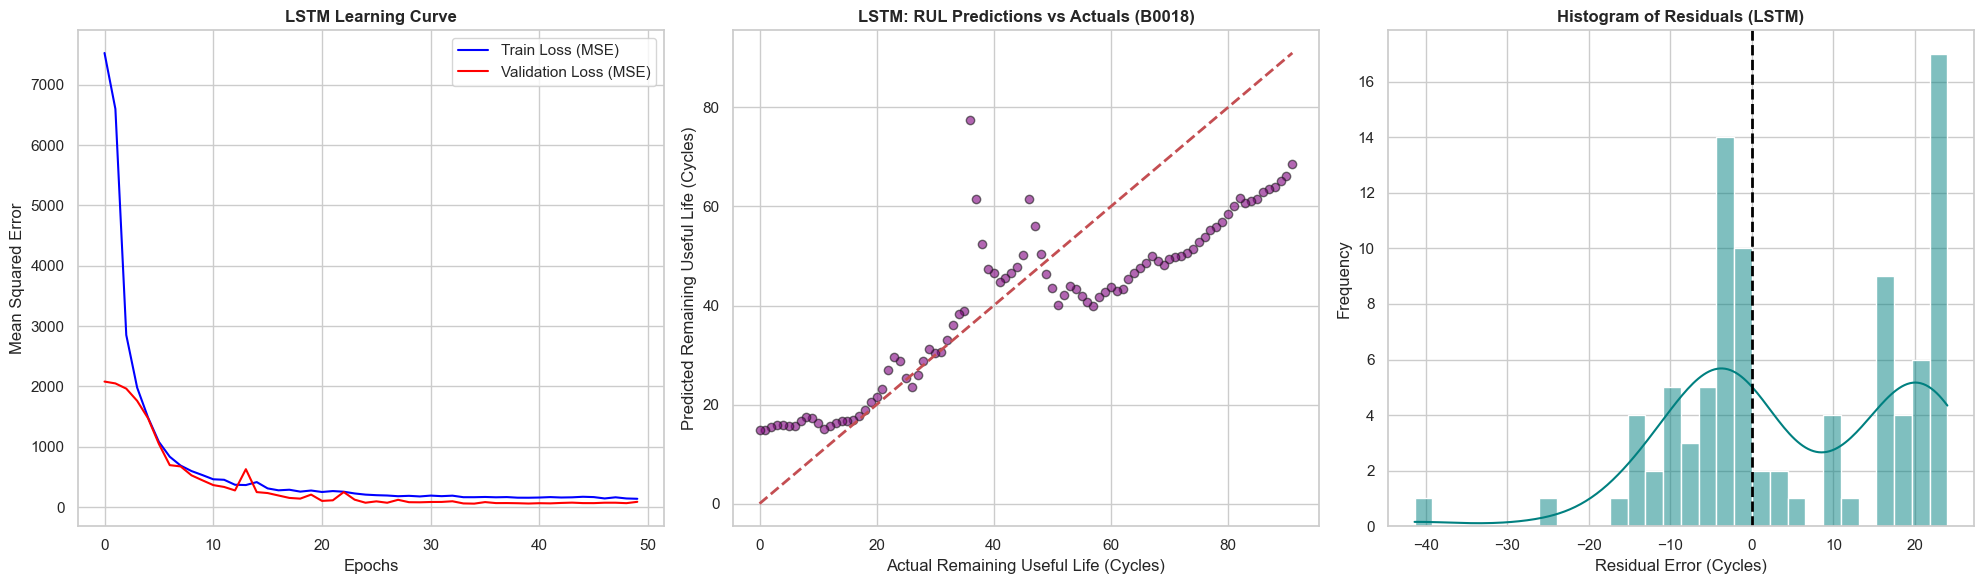


LSTM Model and Scaler successfully saved!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib


test_battery_id = 'B0018'

train_df = df[df['battery'] != test_battery_id]
test_df = df[df['battery'] == test_battery_id]

print(f"Training on batteries: {train_df['battery'].unique()}")
print(f"Testing entirely on unseen battery: {test_battery_id}")

X_train = train_df.drop(columns=['RUL', 'battery', 'cycle'])
y_train = train_df['RUL']

X_test = test_df.drop(columns=['RUL', 'battery', 'cycle'])
y_test = test_df['RUL']

# --- 2. Scaling (CRITICAL FOR NEURAL NETWORKS) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- 3. Create Time-Series Sequences (3D Reshaping) ---
# We will use a sliding window of 5 cycles to give the LSTM "memory"
def create_sequences(X, y, time_steps=5):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 5
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, time_steps)

print(f"LSTM Input Shape: {X_train_seq.shape} -> (Samples, Time Steps, Features)")


# --- 4. Build and Train the LSTM ---
print("\nBuilding LSTM Architecture...")
model = Sequential([
    # Layer 1: LSTM with return_sequences=True to stack another LSTM
    LSTM(64, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=True),
    Dropout(0.2), # Prevent overfitting
    
    # Layer 2: Final LSTM
    LSTM(32, activation='relu'),
    
    # Layer 3: Fully connected Dense layers
    Dense(16, activation='relu'),
    Dense(1) # Output layer (Predicts single RUL value)
])

model.compile(optimizer='adam', loss='mse')

# Stop training if validation loss doesn't improve for 15 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Training LSTM (This may take a minute)...")
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=150,
    batch_size=16,
    validation_split=0.2, # Use 20% of training data to monitor for overfitting
    callbacks=[early_stop],
    verbose=1 # Shows progress bar
)


# --- 5. Final Evaluation Metrics ---
print("\n--- Final LSTM Evaluation ---")
y_pred_seq = model.predict(X_test_seq).flatten()
y_pred_seq = np.maximum(y_pred_seq, 0) # RUL cannot be negative

rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred_seq))
mae = mean_absolute_error(y_test_seq, y_pred_seq)
r2 = r2_score(y_test_seq, y_pred_seq)

# SAFE RELATIVE ERROR (MAPE)
mask = y_test_seq > 0
safe_mape = np.mean(np.abs((y_test_seq[mask] - y_pred_seq[mask]) / y_test_seq[mask])) * 100

print(f"RMSE:             {rmse:.2f} cycles")
print(f"MAE:              {mae:.2f} cycles")
print(f"Relative Error:   {safe_mape:.2f}%")
print(f"R²:               {r2:.4f}")


# --- 6. Plotting & Diagnostics ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot A: LSTM Training vs Validation Loss (Learning Curve)
axes[0].plot(history.history['loss'], label='Train Loss (MSE)', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss (MSE)', color='red')
axes[0].set_title('LSTM Learning Curve', fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend()

# Plot B: Actual vs Predicted
axes[1].scatter(y_test_seq, y_pred_seq, alpha=0.6, color='purple', edgecolors='k')
axes[1].plot([y_test_seq.min(), y_test_seq.max()], [y_test_seq.min(), y_test_seq.max()], 'r--', lw=2)
axes[1].set_title(f'LSTM: RUL Predictions vs Actuals ({test_battery_id})', fontweight='bold')
axes[1].set_xlabel('Actual Remaining Useful Life (Cycles)')
axes[1].set_ylabel('Predicted Remaining Useful Life (Cycles)')

# Plot C: Histogram of Residuals
residuals = y_test_seq - y_pred_seq
sns.histplot(residuals, kde=True, ax=axes[2], color='teal', bins=30)
axes[2].axvline(0, color='black', linestyle='--', lw=2)
axes[2].set_title('Histogram of Residuals (LSTM)', fontweight='bold')
axes[2].set_xlabel('Residual Error (Cycles)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# --- 7. SAVE THE MODEL AND SCALER ---
model.save('battery_rul_lstm.keras')
joblib.dump(scaler, 'battery_rul_lstm_scaler.pkl')
print("\nLSTM Model and Scaler successfully saved!")

In [13]:
import joblib
import m2cgen as m2c
import xgboost as xgb

# 1. Load your winning XGBoost model
print("Loading XGBoost model...")
xgb_model = joblib.load("battery_rul_xgboost.pkl")

# 2. Convert the model to C++ code
print("Converting model to raw C++... (This might take a minute for 62 trees)")
# We use the 'score' method for regression tasks
cpp_code = m2c.export_to_c(xgb_model)

# 3. Save the C++ code to a header file for the ESP32
output_filename = "XGBoost_RUL_Model.h"
with open(output_filename, "w") as f:
    f.write(cpp_code)

print(f"\nSuccess! Model converted and saved as {output_filename}")
print("You can now include this in your Arduino IDE / PlatformIO project.")

Loading XGBoost model...
Converting model to raw C++... (This might take a minute for 62 trees)

Success! Model converted and saved as XGBoost_RUL_Model.h
You can now include this in your Arduino IDE / PlatformIO project.
